# Step 2: Exploratory Data Analysis

This notebook explores trends, distributions, correlations, and anomalies in AAPL stock data using the existing project data loader.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS_DIR = ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Outputs dir: {OUTPUTS_DIR}")

Project root: D:\Projects\stock-price-prediction
Outputs dir: D:\Projects\stock-price-prediction\outputs


In [3]:
from src.data_loader import StockDataConfig, load_stock_data

config = StockDataConfig(ticker="AAPL", period="10y", missing_value_strategy="drop")
df = load_stock_data(config)

expected_columns = ["Open", "High", "Low", "Close", "Volume"]
assert list(df.columns) == expected_columns, f"Unexpected columns: {df.columns.tolist()}"
assert df.index.is_monotonic_increasing, "Index must be sorted ascending"
assert not df.index.has_duplicates, "Duplicate timestamps detected"

print(f"Loaded rows: {len(df)}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")
df.head()

Raw CSV saved to: data\AAPL_10y_1d_raw_20260413T070634Z.csv
Shape: (2515, 5)
Head:
                 Open       High        Low      Close     Volume
Date                                                             
2016-04-11  27.242500  27.652500  27.207500  27.254999  117630000
2016-04-12  27.334999  27.625000  27.165001  27.610001  108929200
2016-04-13  27.700001  28.084999  27.700001  28.010000  133029200
2016-04-14  27.905001  28.097500  27.832500  28.025000  101895600
2016-04-15  28.027500  28.075001  27.432501  27.462500  187756000
Tail:
                  Open        High         Low       Close    Volume
Date                                                                
2026-04-06  256.510010  262.160004  256.459991  258.859985  29329900
2026-04-07  256.160004  256.200012  245.699997  253.500000  62148000
2026-04-08  258.450012  259.750000  256.529999  258.899994  41032800
2026-04-09  259.000000  261.119995  256.070007  260.489990  28121600
2026-04-10  259.980011  262.190002 

,Open,High,Low,Close,Volume
Date,,,,,
2016-04-11,27.242500,27.652500,27.207500,27.254999,117630000
2016-04-12,27.334999,27.625000,27.165001,27.610001,108929200
2016-04-13,27.700001,28.084999,27.700001,28.010000,133029200
2016-04-14,27.905001,28.097500,27.832500,28.025000,101895600
2016-04-15,28.027500,28.075001,27.432501,27.462500,187756000


## Trend Analysis

Plot closing price and trading volume over time to inspect long-term trends and notable regime changes.

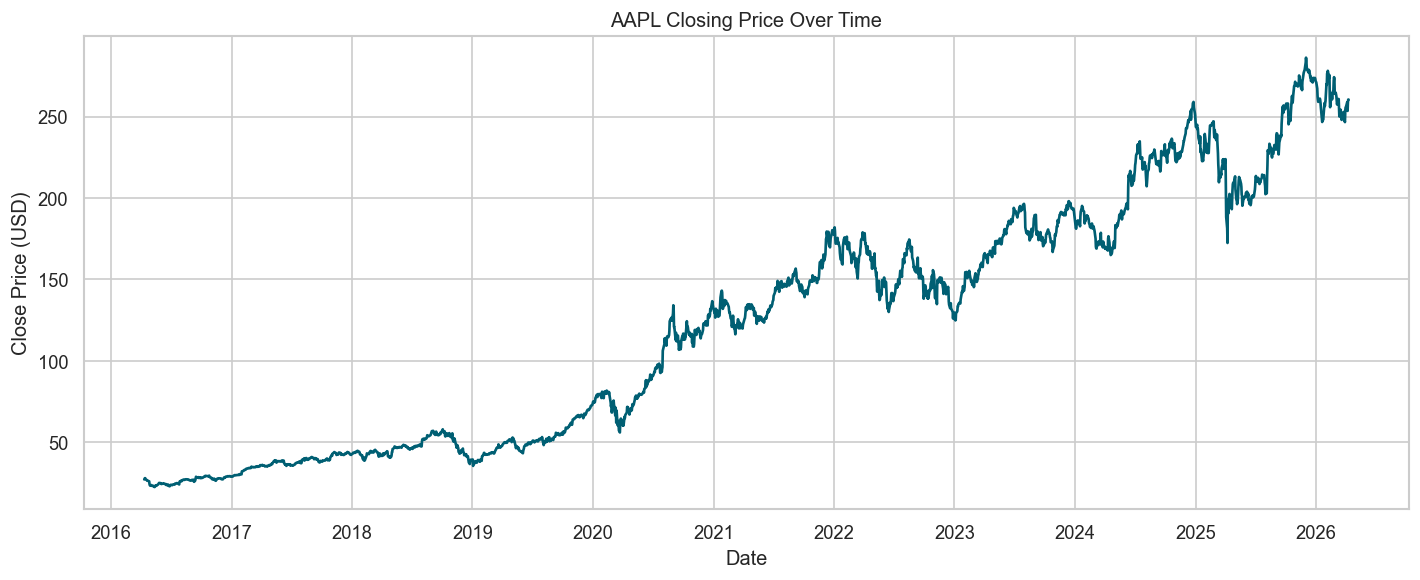

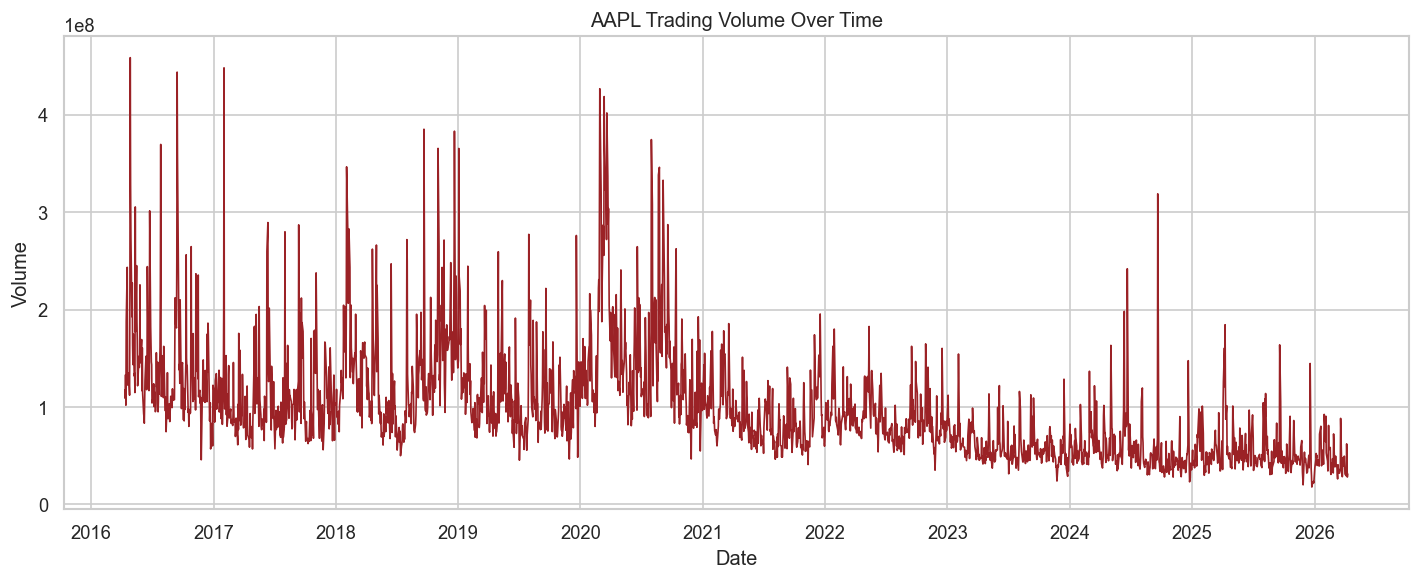

Saved: D:\Projects\stock-price-prediction\outputs\eda_close_over_time.png
Saved: D:\Projects\stock-price-prediction\outputs\eda_volume_over_time.png


In [4]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="#005f73", linewidth=1.6)
ax.set_title("AAPL Closing Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
close_plot_path = OUTPUTS_DIR / "eda_close_over_time.png"
fig.tight_layout()
fig.savefig(close_plot_path, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots()
ax.plot(df.index, df["Volume"], color="#9b2226", linewidth=1.0)
ax.set_title("AAPL Trading Volume Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Volume")
volume_plot_path = OUTPUTS_DIR / "eda_volume_over_time.png"
fig.tight_layout()
fig.savefig(volume_plot_path, bbox_inches="tight")
plt.show()

print(f"Saved: {close_plot_path}")
print(f"Saved: {volume_plot_path}")

## Summary Statistics and Correlations

Review central tendency/spread and feature relationships across OHLCV variables.

In [5]:
summary_stats = df.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
Open,2515.0,1.227364e+02,7.487011e+01,2.250000e+01,4.658000e+01,1.294100e+02,1.787150e+02,2.862000e+02
High,2515.0,1.240660e+02,7.565021e+01,2.291750e+01,4.700000e+01,1.310000e+02,1.803600e+02,2.886200e+02
Low,2515.0,1.215028e+02,7.413330e+01,2.236750e+01,4.624125e+01,1.280400e+02,1.771950e+02,2.833000e+02
Close,2515.0,1.228405e+02,7.491997e+01,2.258500e+01,4.662875e+01,1.298700e+02,1.790300e+02,2.861900e+02
Volume,2515.0,9.823348e+07,5.595504e+07,1.791060e+07,5.901105e+07,8.631360e+07,1.193392e+08,4.584084e+08


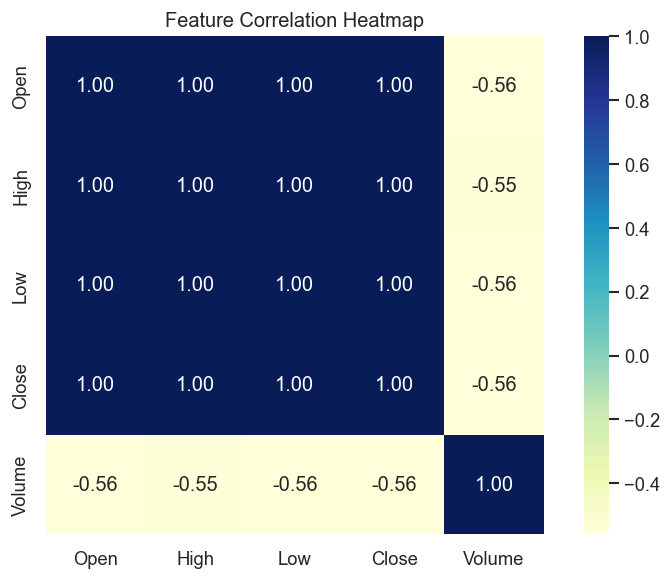

,Open,High,Low,Close,Volume
Open,1.000000,0.999813,0.999822,0.999624,-0.555305
High,0.999813,1.000000,0.999757,0.999830,-0.551353
Low,0.999822,0.999757,1.000000,0.999827,-0.559345
Close,0.999624,0.999830,0.999827,1.000000,-0.555466
Volume,-0.555305,-0.551353,-0.559345,-0.555466,1.000000


In [6]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", square=True, ax=ax)
ax.set_title("Feature Correlation Heatmap")
heatmap_path = OUTPUTS_DIR / "eda_correlation_heatmap.png"
fig.tight_layout()
fig.savefig(heatmap_path, bbox_inches="tight")
plt.show()

corr

## Outliers and Abnormal Spikes

Use IQR-based outlier counts and z-score spikes to spot abnormal behavior in prices and volume.

In [7]:
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]

iqr_outlier_counts = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

outlier_summary = pd.Series(iqr_outlier_counts, name="IQR Outlier Count")
outlier_summary

Open        0
High        0
Low         0
Close       0
Volume    109
Name: IQR Outlier Count, dtype: int64

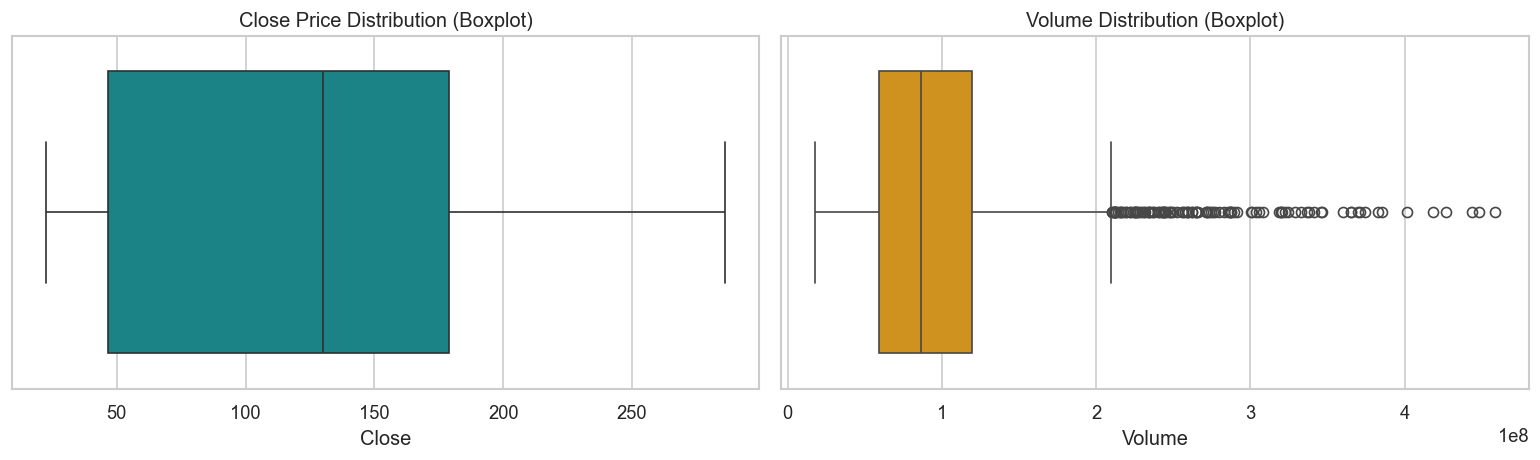

Close z-score spikes (>3): 0
Volume z-score spikes (>3): 49
Saved: D:\Projects\stock-price-prediction\outputs\eda_outlier_boxplots.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=df["Close"], ax=axes[0], color="#0a9396")
axes[0].set_title("Close Price Distribution (Boxplot)")
sns.boxplot(x=df["Volume"], ax=axes[1], color="#ee9b00")
axes[1].set_title("Volume Distribution (Boxplot)")

outlier_plot_path = OUTPUTS_DIR / "eda_outlier_boxplots.png"
fig.tight_layout()
fig.savefig(outlier_plot_path, bbox_inches="tight")
plt.show()

close_z = ((df["Close"] - df["Close"].mean()) / df["Close"].std(ddof=0)).abs()
volume_z = ((df["Volume"] - df["Volume"].mean()) / df["Volume"].std(ddof=0)).abs()
close_spikes = int((close_z > 3).sum())
volume_spikes = int((volume_z > 3).sum())

print(f"Close z-score spikes (>3): {close_spikes}")
print(f"Volume z-score spikes (>3): {volume_spikes}")
print(f"Saved: {outlier_plot_path}")

In [9]:
expected_output_files = [
    OUTPUTS_DIR / "eda_close_over_time.png",
    OUTPUTS_DIR / "eda_volume_over_time.png",
    OUTPUTS_DIR / "eda_correlation_heatmap.png",
    OUTPUTS_DIR / "eda_outlier_boxplots.png",
]

missing = [str(p) for p in expected_output_files if not p.exists()]
assert not missing, f"Missing output files: {missing}"

print("All expected EDA plots were generated:")
for p in expected_output_files:
    print(f"- {p}")

All expected EDA plots were generated:
- D:\Projects\stock-price-prediction\outputs\eda_close_over_time.png
- D:\Projects\stock-price-prediction\outputs\eda_volume_over_time.png
- D:\Projects\stock-price-prediction\outputs\eda_correlation_heatmap.png
- D:\Projects\stock-price-prediction\outputs\eda_outlier_boxplots.png


## Brief Observations

- Closing price shows a strong long-term upward trend with intermittent drawdowns and recovery phases.
- Volume contains multiple high-intensity spikes, often corresponding to high-volatility periods.
- OHLC features are highly positively correlated, which is expected for same-asset daily bars.
- Outlier and z-score checks confirm abnormal spikes are concentrated mainly in Volume and, to a lesser extent, in Close.
- No unexpected feature distributions were observed for this daily OHLCV dataset beyond known market-event spikes.